# Relevance filtering

### Rate relevance original prompt

In [7]:
import json
import os
import re
from pathlib import Path
from dotenv import load_dotenv
from groq import Groq
from tqdm import tqdm

# ----------------------------
# Configuration
# ----------------------------

INPUT_PATH = "data/political_markets/comparison/articles_scored.json"
OUTPUT_PATH = "data/political_markets/comparison/articles_scored.json"

MODEL = "llama-3.3-70b-versatile"

SAVE_EVERY_N_ARTICLES = 10

# ----------------------------
# Load API keys / clients
# ----------------------------

load_dotenv()

API_KEYS = [
    os.getenv("GROQ_API_KEY_1"),
    os.getenv("GROQ_API_KEY_2"),
    os.getenv("GROQ_API_KEY_3"),
    os.getenv("GROQ_API_KEY_4"),
]

API_KEYS = [k for k in API_KEYS if k]

if not API_KEYS:
    raise ValueError("No Groq API keys found.")

clients = [Groq(api_key=key) for key in API_KEYS]

current_client_idx = 0

# ----------------------------
# Load existing scored file
# ----------------------------

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

# ----------------------------
# Prompt template
# ----------------------------

PROMPT_TEMPLATE = """Please consider the following forecasting question and its background information. After that, I will give
you a news article and ask you to rate its relevance with respect to the forecasting question.

Question: {question}

Resolution Criteria:
{resolution_criteria}

Article:
{article}

Please rate the relevance of the article to the question, at the scale of 1-6

1 – irrelevant
2 – slightly relevant
3 – somewhat relevant
4 – relevant
5 – highly relevant
6 – most relevant

Guidelines:
- You don’t need to access any external sources. Just consider the information provided.
- Focus on the content of the article, not the title.
- If the text content is an error message about JavaScript, paywall, cookies or other technical issues,
output a score of 1.

Your response should look like the following:

Thought: {{ Insert your thinking }}
Rating: {{ Insert answer here }}
"""

# ----------------------------
# Helper functions
# ----------------------------

def extract_thought_and_rating(response_text):
    """
    Extract:
    - thought (string)
    - rating (int)
    """

    thought_match = re.search(
        r"Thought:\s*(.*?)(?:Rating:|$)",
        response_text,
        re.DOTALL | re.IGNORECASE,
    )

    rating_match = re.search(
        r"Rating:\s*([1-6])",
        response_text,
        re.IGNORECASE,
    )

    thought = (
        thought_match.group(1).strip()
        if thought_match
        else None
    )

    rating = (
        int(rating_match.group(1))
        if rating_match
        else None
    )

    return thought, rating


def save_progress():
    Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
        json.dump(markets, f, ensure_ascii=False, indent=2)


def get_completion_with_failover(messages):
    global current_client_idx

    num_clients = len(clients)
    attempts = 0

    while attempts < num_clients:

        client = clients[current_client_idx]

        try:
            completion = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                temperature=0,
            )

            return completion

        except Exception as e:
            error_text = str(e).lower()

            quota_error = any(
                phrase in error_text
                for phrase in [
                    "rate limit",
                    "quota",
                    "credit",
                    "exceeded",
                    "insufficient",
                    "429",
                ]
            )

            if quota_error:
                print(
                    f"\nAPI key #{current_client_idx + 1} exhausted or rate-limited. "
                    f"Switching to next key..."
                )

                current_client_idx = (current_client_idx + 1) % num_clients
                attempts += 1

            else:
                raise e

    raise RuntimeError("All Groq API keys failed or exhausted.")


def score_article(question, resolution_criteria, article_text):

    prompt = PROMPT_TEMPLATE.format(
        question=question,
        resolution_criteria=resolution_criteria,
        article=article_text,
    )

    completion = get_completion_with_failover(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ]
    )

    response_text = completion.choices[0].message.content

    thought, rating = extract_thought_and_rating(response_text)

    return {
        "llm_response": response_text,
        "thought": thought,
        "rating": rating,
    }


# ----------------------------
# Count remaining articles
# ----------------------------

articles_to_process = []

for market in markets:

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            if article.get("rating") is None:
                articles_to_process.append((market, article))

print(f"Articles remaining: {len(articles_to_process)}")

# ----------------------------
# Process only missing ratings
# ----------------------------

processed_since_save = 0

progress_bar = tqdm(
    total=len(articles_to_process),
    desc="Scoring missing articles",
)

for market, article in articles_to_process:

    question = market.get("question", "")
    resolution_criteria = market.get("resolution_criteria", "")

    article_text = article.get("full_text", "")

    try:
        result = score_article(
            question=question,
            resolution_criteria=resolution_criteria,
            article_text=article_text,
        )

        article["llm_response"] = result["llm_response"]
        article["thought"] = result["thought"]
        article["rating"] = result["rating"]

        # remove previous error if retry succeeds
        if "error" in article:
            del article["error"]

    except Exception as e:

        article["llm_response"] = None
        article["thought"] = None
        article["rating"] = None
        article["error"] = str(e)

        print(f"\nError: {e}")

    processed_since_save += 1
    progress_bar.update(1)

    # periodic checkpoint save
    if processed_since_save >= SAVE_EVERY_N_ARTICLES:
        save_progress()
        processed_since_save = 0
        print("\nProgress saved.")

progress_bar.close()

# ----------------------------
# Final save
# ----------------------------

save_progress()

print(f"Finished. Updated file saved to: {OUTPUT_PATH}")

Articles remaining: 230


Scoring missing articles:   4%|▍         | 10/230 [00:28<17:40,  4.82s/it]


Progress saved.


Scoring missing articles:   9%|▊         | 20/230 [01:36<21:14,  6.07s/it]


Progress saved.


...


API key #1 exhausted or rate-limited. Switching to next key...

API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

API key #4 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.


Scoring missing articles: 100%|█████████▉| 229/230 [21:48<00:00,  3.70it/s]


API key #1 exhausted or rate-limited. Switching to next key...

API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

API key #4 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.

API key #1 exhausted or rate-limited. Switching to next key...


Scoring missing articles: 100%|██████████| 230/230 [21:48<00:00,  5.69s/it]


API key #2 exhausted or rate-limited. Switching to next key...

API key #3 exhausted or rate-limited. Switching to next key...

API key #4 exhausted or rate-limited. Switching to next key...

Error: All Groq API keys failed or exhausted.

Progress saved.
Finished. Updated file saved to: data/political_markets/comparison/articles_scored.json


Total rated articles: 531
Average score: 2.844


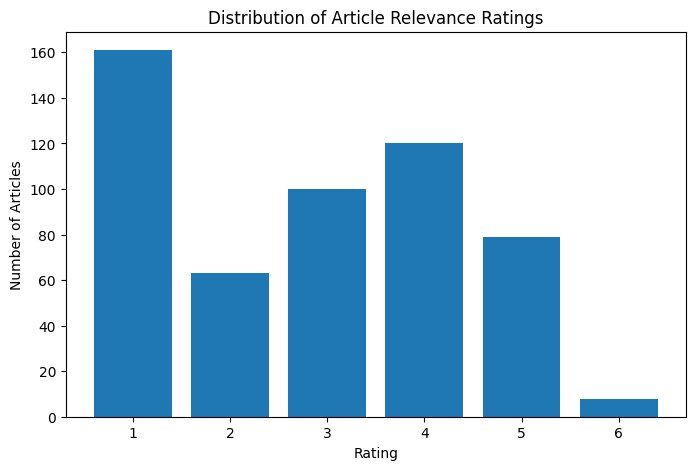

In [8]:
import json
from collections import Counter

import matplotlib.pyplot as plt

# ----------------------------
# Load scored dataset
# ----------------------------

INPUT_PATH = "data/political_markets/comparison/articles_scored.json"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

# ----------------------------
# Collect ratings
# ----------------------------

ratings = []

for market in markets:
    for query_obj in market.get("queries", []):
        for article in query_obj.get("articles", []):

            rating = article.get("rating")

            if isinstance(rating, int):
                ratings.append(rating)

# ----------------------------
# Summary statistics
# ----------------------------

total_rated_articles = len(ratings)

average_score = (
    sum(ratings) / total_rated_articles
    if total_rated_articles > 0
    else 0
)

print(f"Total rated articles: {total_rated_articles}")
print(f"Average score: {average_score:.3f}")

# ----------------------------
# Rating distribution
# ----------------------------

rating_counts = Counter(ratings)

x = [1, 2, 3, 4, 5, 6]
y = [rating_counts.get(i, 0) for i in x]

# ----------------------------
# Bar plot
# ----------------------------

plt.figure(figsize=(8, 5))
plt.bar(x, y)

plt.xticks(x)
plt.xlabel("Rating")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Relevance Ratings")

plt.show()

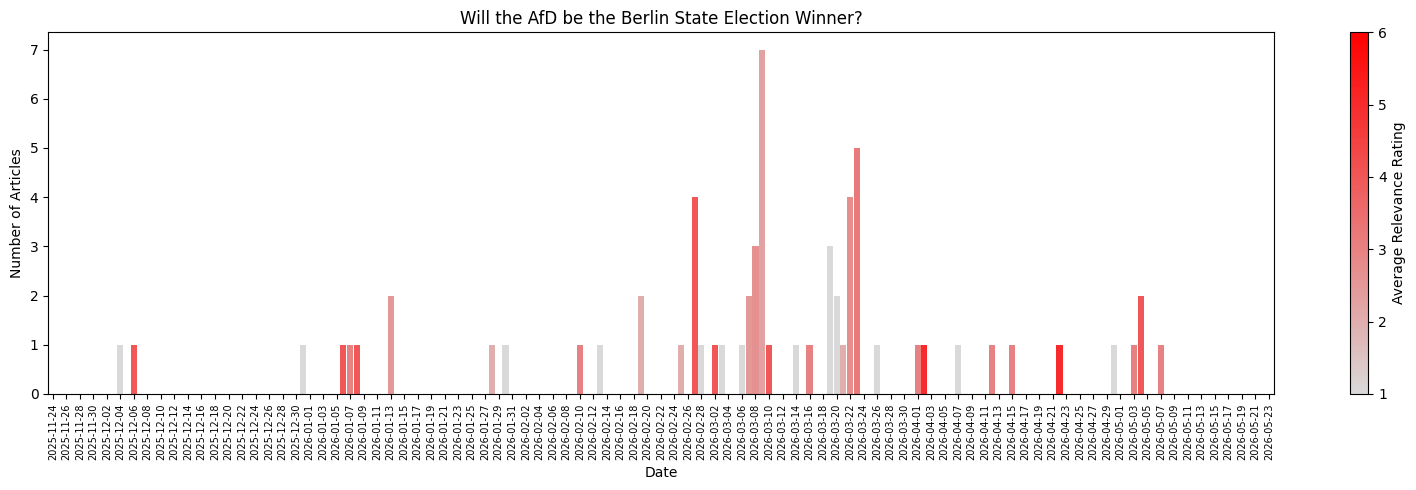

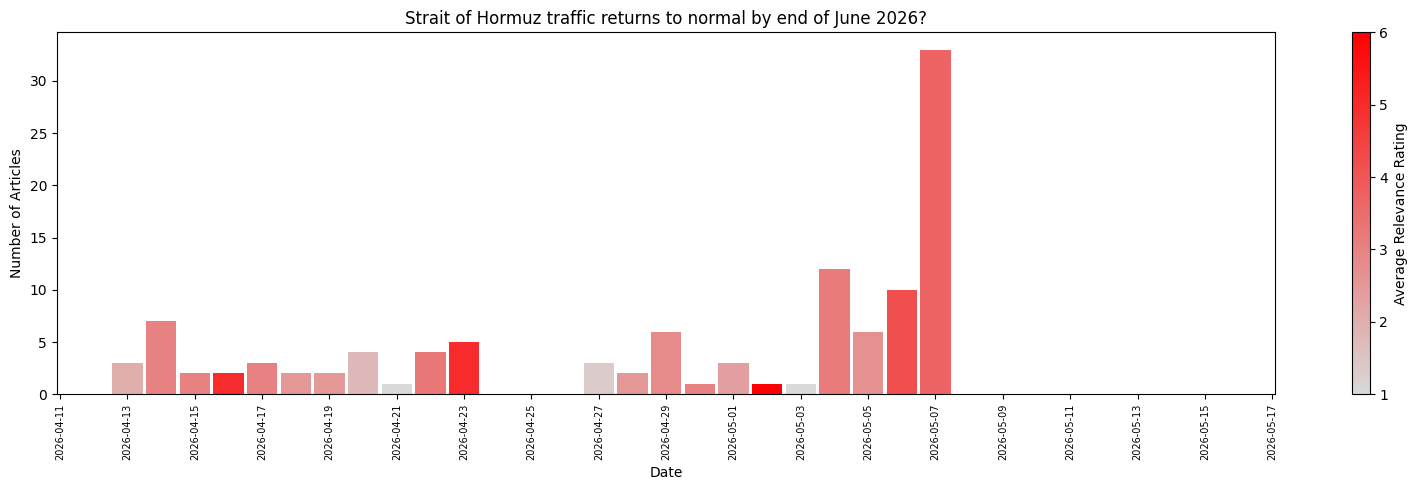

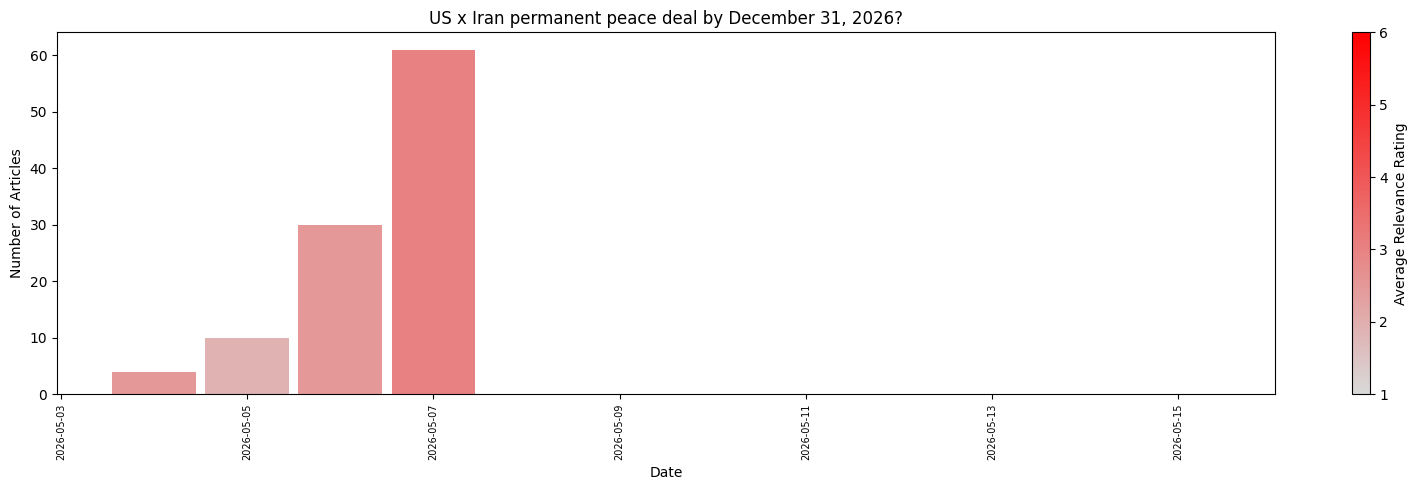

In [32]:
import json
from collections import defaultdict
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

SCORED_PATH = "data/political_markets/comparison/articles_scored.json"
MARKETS_PATH = "data/political_markets/markets.json"

with open(SCORED_PATH, "r", encoding="utf-8") as f:
    scored_markets = json.load(f)

with open(MARKETS_PATH, "r", encoding="utf-8") as f:
    markets_metadata = json.load(f)

market_lookup = {}

for market in markets_metadata:

    question = market.get("question")
    start_date = market.get("start_date")

    if question and start_date:
        market_lookup[question] = start_date

today = datetime.now(timezone.utc).date()

# ============================================================
# Create one plot per market
# ============================================================

for market in scored_markets:

    question = market.get("question", "Unknown Market")

    if question not in market_lookup:
        print(f"Skipping market (missing start_date): {question}")
        continue

    # --------------------------------------------------------
    # Parse start date
    # --------------------------------------------------------

    start_date = pd.to_datetime(
        market_lookup[question],
        utc=True,
        errors="coerce",
    )

    if pd.isna(start_date):
        print(f"Skipping market (invalid start_date): {question}")
        continue

    start_date = start_date.date()

    # --------------------------------------------------------
    # Aggregate per-day statistics
    # --------------------------------------------------------

    articles_per_day = defaultdict(int)
    ratings_per_day = defaultdict(list)

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            published_date = article.get("published_date")

            if not published_date:
                continue

            published_dt = pd.to_datetime(
                published_date,
                utc=True,
                errors="coerce",
            )

            if pd.isna(published_dt):
                continue

            published_day = published_dt.date()

            # filter by start_date -> today
            if not (start_date <= published_day <= today):
                continue

            rating = article.get("rating")

            # missing ratings count as 1
            if not isinstance(rating, int):
                rating = 1

            articles_per_day[published_day] += 1
            ratings_per_day[published_day].append(rating)

    # --------------------------------------------------------
    # Skip empty markets
    # --------------------------------------------------------

    if not articles_per_day:
        print(f"No articles in range for: {question}")
        continue

    # --------------------------------------------------------
    # Create continuous date range
    # --------------------------------------------------------

    all_days = pd.date_range(start=start_date, end=today, freq="D")

    counts = []
    avg_ratings = []

    for day in all_days:

        d = day.date()

        counts.append(articles_per_day.get(d, 0))

        ratings = ratings_per_day.get(d, [])

        if ratings:
            avg_ratings.append(sum(ratings) / len(ratings))
        else:
            avg_ratings.append(1)

    # --------------------------------------------------------
    # Normalize colors by average rating
    # --------------------------------------------------------

    norm = mcolors.Normalize(vmin=1, vmax=6)

    # light grey -> bright red
    cmap = LinearSegmentedColormap.from_list(
        "grey_to_red",
        ["#d9d9d9", "#ff0000"]
    )

    colors = [cmap(norm(r)) for r in avg_ratings]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(16, 5))

    plt.bar(
        all_days,
        counts,
        color=colors,
        width=0.9,
    )

    plt.xlabel("Date")
    plt.ylabel("Number of Articles")
    plt.title(question)

    ax = plt.gca()

    # more frequent x-axis labels
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

    # format labels
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m-%d")
    )

    plt.xticks(rotation=90, fontsize=7)

    # colorbar for average relevance
    ax = plt.gca()

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Average Relevance Rating")

    plt.tight_layout()
    plt.show()

In [10]:
from collections import defaultdict
import pandas as pd

# ------------------------------------------------------------
# Print days where average relevance rating > 4
# ------------------------------------------------------------

for market in scored_markets:

    question = market.get("question", "Unknown Market")

    ratings_per_day = defaultdict(list)

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            published_date = article.get("published_date")

            if not published_date:
                continue

            published_dt = pd.to_datetime(
                published_date,
                utc=True,
                errors="coerce",
            )

            if pd.isna(published_dt):
                continue

            published_day = published_dt.date()

            rating = article.get("rating")

            # missing ratings count as 1
            if not isinstance(rating, int):
                rating = 1

            ratings_per_day[published_day].append(rating)

    high_relevance_days = []

    for day, ratings in ratings_per_day.items():

        avg_rating = sum(ratings) / len(ratings)

        if avg_rating > 4:
            high_relevance_days.append(
                (day, round(avg_rating, 2), len(ratings))
            )

    if high_relevance_days:

        print(f"\n=== {question} ===")

        for day, avg_rating, n_articles in sorted(high_relevance_days):

            print(
                f"{day} | avg rating = {avg_rating} | "
                f"articles = {n_articles}"
            )


=== Will the AfD be the Berlin State Election Winner? ===
2016-09-18 | avg rating = 5.0 | articles = 1
2025-01-25 | avg rating = 5.0 | articles = 1
2025-03-03 | avg rating = 4.5 | articles = 2
2025-10-30 | avg rating = 5.0 | articles = 2
2026-04-02 | avg rating = 5.0 | articles = 1
2026-04-22 | avg rating = 5.0 | articles = 1

=== Strait of Hormuz traffic returns to normal by end of June 2026? ===
2026-03-03 | avg rating = 5.0 | articles = 1
2026-03-10 | avg rating = 5.0 | articles = 1
2026-03-18 | avg rating = 5.0 | articles = 1
2026-03-24 | avg rating = 5.5 | articles = 2
2026-04-05 | avg rating = 6.0 | articles = 1
2026-04-10 | avg rating = 6.0 | articles = 1
2026-04-12 | avg rating = 5.0 | articles = 1
2026-04-16 | avg rating = 5.0 | articles = 2
2026-04-23 | avg rating = 5.0 | articles = 5
2026-05-02 | avg rating = 6.0 | articles = 1
2026-05-06 | avg rating = 4.2 | articles = 10

=== US x Iran permanent peace deal by December 31, 2026? ===
2026-04-12 | avg rating = 4.33 | article

### Rate relevance prompt with published date

In [ ]:
# PROMPT WITH PUBLISHED DATE

import json
import os
import re
from pathlib import Path

from dotenv import load_dotenv
from groq import Groq
from tqdm import tqdm

INPUT_PATH = "data/political_markets/comparison/articles_scored.json"
OUTPUT_PATH = "data/political_markets/comparison/articles_scored_2.json"

MODEL = "llama-3.3-70b-versatile"

SAVE_EVERY_N_ARTICLES = 10

load_dotenv()

API_KEYS = [
    os.getenv("GROQ_API_KEY_1"),
    os.getenv("GROQ_API_KEY_2"),
    os.getenv("GROQ_API_KEY_3"),
    os.getenv("GROQ_API_KEY_4"),
]

API_KEYS = [k for k in API_KEYS if k]

if not API_KEYS:
    raise ValueError("No Groq API keys found.")

clients = [Groq(api_key=key) for key in API_KEYS]

current_client_idx = 0

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

PROMPT_TEMPLATE = """Please consider the following forecasting question and its background information. After that, I will give
you a news article and ask you to rate its relevance with respect to the forecasting question.

Question: {question}

Resolution Criteria:
{resolution_criteria}

Article:
{article}

Article Published Date: {published_date}

Please rate the relevance of the article to the question, at the scale of 1-6

1 – irrelevant
2 – slightly relevant
3 – somewhat relevant
4 – relevant
5 – highly relevant
6 – most relevant

Guidelines:
- You don’t need to access any external sources. Just consider the information provided.
- Focus on the content of the article, not the title.
- If the text content is an error message about JavaScript, paywall, cookies or other technical issues,
output a score of 1.

Your response should look like the following:

Thought: {{ Insert your thinking }}
Rating: {{ Insert answer here }}
"""

# ----------------------------
# Helper functions
# ----------------------------

def extract_thought_and_rating(response_text):

    thought_match = re.search(
        r"Thought:\s*(.*?)(?:Rating:|$)",
        response_text,
        re.DOTALL | re.IGNORECASE,
    )

    rating_match = re.search(
        r"Rating:\s*([1-6])",
        response_text,
        re.IGNORECASE,
    )

    thought = (
        thought_match.group(1).strip()
        if thought_match
        else None
    )

    rating = (
        int(rating_match.group(1))
        if rating_match
        else None
    )

    return thought, rating


def save_progress():
    Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)

    with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
        json.dump(markets, f, ensure_ascii=False, indent=2)


def get_completion_with_failover(messages):
    global current_client_idx

    num_clients = len(clients)
    attempts = 0

    while attempts < num_clients:

        client = clients[current_client_idx]

        try:
            completion = client.chat.completions.create(
                model=MODEL,
                messages=messages,
                temperature=0,
            )

            return completion

        except Exception as e:
            error_text = str(e).lower()

            quota_error = any(
                phrase in error_text
                for phrase in [
                    "rate limit",
                    "quota",
                    "credit",
                    "exceeded",
                    "insufficient",
                    "429",
                ]
            )

            if quota_error:
                print(
                    f"\nAPI key #{current_client_idx + 1} exhausted or rate-limited. "
                    f"Switching to next key..."
                )

                current_client_idx = (current_client_idx + 1) % num_clients
                attempts += 1

            else:
                raise e

    raise RuntimeError("All Groq API keys failed or exhausted.")


def score_article(question, resolution_criteria, article_text, published_date):

    prompt = PROMPT_TEMPLATE.format(
        question=question,
        resolution_criteria=resolution_criteria,
        article=article_text,
        published_date=published_date
    )

    completion = get_completion_with_failover(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ]
    )

    response_text = completion.choices[0].message.content

    thought, rating = extract_thought_and_rating(response_text)

    return {
        "llm_response": response_text,
        "thought": thought,
        "rating": rating,
    }

articles_to_process = []

for market in markets:

    for query_obj in market.get("queries", []):

        for article in query_obj.get("articles", []):

            if article.get("rating") is None:
                articles_to_process.append((market, article))

print(f"Articles remaining: {len(articles_to_process)}")

processed_since_save = 0

progress_bar = tqdm(
    total=len(articles_to_process),
    desc="Scoring missing articles",
)

for market, article in articles_to_process:

    question = market.get("question", "")
    resolution_criteria = market.get("resolution_criteria", "")
    article_text = article.get("full_text", "")
    published_date = article.get("published_date", "")

    try:
        result = score_article(
            question=question,
            resolution_criteria=resolution_criteria,
            article_text=article_text,
            published_date=published_date
        )

        article["llm_response"] = result["llm_response"]
        article["thought"] = result["thought"]
        article["rating"] = result["rating"]

        # remove previous error if retry succeeds
        if "error" in article:
            del article["error"]

    except Exception as e:

        article["llm_response"] = None
        article["thought"] = None
        article["rating"] = None
        article["error"] = str(e)

        print(f"\nError: {e}")

    processed_since_save += 1
    progress_bar.update(1)

    # periodic checkpoint save
    if processed_since_save >= SAVE_EVERY_N_ARTICLES:
        save_progress()
        processed_since_save = 0
        print("\nProgress saved.")

progress_bar.close()

save_progress()

print(f"Finished. Updated file saved to: {OUTPUT_PATH}")

Articles remaining: 331


Scoring missing articles:  48%|████▊     | 160/331 [13:49:11<14:46:12, 310.95s/it]


KeyboardInterrupt: 

In [ ]:
import json
from collections import Counter

import matplotlib.pyplot as plt

# ----------------------------
# Load scored dataset
# ----------------------------

INPUT_PATH = "data/political_markets/comparison/articles_scored_2.json"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    markets = json.load(f)

# ----------------------------
# Collect ratings
# ----------------------------

ratings = []

for market in markets:
    for query_obj in market.get("queries", []):
        for article in query_obj.get("articles", []):

            rating = article.get("rating")

            if isinstance(rating, int):
                ratings.append(rating)

# ----------------------------
# Summary statistics
# ----------------------------

total_rated_articles = len(ratings)

average_score = (
    sum(ratings) / total_rated_articles
    if total_rated_articles > 0
    else 0
)

print(f"Total rated articles: {total_rated_articles}")
print(f"Average score: {average_score:.3f}")

# ----------------------------
# Rating distribution
# ----------------------------

rating_counts = Counter(ratings)

x = [1, 2, 3, 4, 5, 6]
y = [rating_counts.get(i, 0) for i in x]

# ----------------------------
# Bar plot
# ----------------------------

plt.figure(figsize=(8, 5))
plt.bar(x, y)

plt.xticks(x)
plt.xlabel("Rating")
plt.ylabel("Number of Articles")
plt.title("Distribution of Article Relevance Ratings")

plt.show()

### Comparison 2x2 (with/without date & score/probability) - 4 markets (Iran, Taiwan, AI bubble, Eurovision)

In [3]:
import json
import os
import re
from datetime import datetime
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

client = Groq(api_key=os.getenv("GROQ_API_KEY_5"))
MODEL = "llama-3.3-70b-versatile"
TODAY = datetime.today().strftime("%Y-%m-%d")

# Load prompts
def load_prompt(name):
    with open(f"prompts/relevance/{name}.txt", "r") as f:
        return f.read()

prompts = {
    "probability_with_date":    load_prompt("probability_with_date"),
    "probability_without_date": load_prompt("probability_without_date"),
    "score_with_date":          load_prompt("score_with_date"),
    "score_without_date":       load_prompt("score_without_date"),
}

# Load markets
with open("data/news/markets.json", "r") as f:
    markets = json.load(f)


def call_llm(prompt_text):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt_text}],
        temperature=0.0,
    )
    return response.choices[0].message.content


def parse_value(text, label):
    """Extract numeric value after a label like 'Probability:' or 'Score:'"""
    match = re.search(rf"{label}:\s*(-?\d+(?:\.\d+)?)", text, re.IGNORECASE)
    if match:
        val = float(match.group(1))
        return int(val) if val == int(val) else val
    return None


def parse_thought(text):
    """Extract text after 'Thought:' up to the next label"""
    match = re.search(r"Thought:\s*(.*?)(?:\n(?:Probability|Score):|$)", text, re.IGNORECASE | re.DOTALL)
    return match.group(1).strip() if match else text.strip()


def fill_prompt(template, **kwargs):
    for key, val in kwargs.items():
        template = template.replace("{" + key + "}", str(val) if val else "")
    return template


results = []

for market in markets:
    question          = market.get("question", "")
    resolution        = market.get("resolution_criteria", "")
    market_result     = {"question": question, "queries": []}

    for query_obj in market.get("queries", []):
        query_result = {"query": query_obj.get("query", ""), "articles": []}

        for article in query_obj.get("articles", []):
            full_text      = article.get("full_text", "")
            published_date = article.get("published_date", "")

            article_text = f"{article.get('title', '')}\n\n{full_text}"

            common_vars = dict(
                question=question,
                resolution_criteria=resolution,
                article=article_text,
            )
            date_vars = dict(
                published_date=published_date,
                today_date=TODAY,
            )

            article_result = {}

            for prompt_key, label, needs_date in [
                ("probability_with_date",    "Probability", True),
                ("probability_without_date", "Probability", False),
                ("score_with_date",          "Rating",      True),
                ("score_without_date",       "Rating",      False),
            ]:
                vars_to_fill = {**common_vars, **(date_vars if needs_date else {})}
                filled  = fill_prompt(prompts[prompt_key], **vars_to_fill)

                print(f"\n{'='*60}")
                print(f"PROMPT [{prompt_key}]")
                print('='*60)
                print(filled)
                print('='*60)

                raw     = call_llm(filled)

                print(f"RESPONSE [{prompt_key}]:")
                print(raw)

                value   = parse_value(raw, label)
                thought = parse_thought(raw)

                article_result[prompt_key]              = value
                article_result[f"thoughts_{prompt_key}"] = thought

            query_result["articles"].append(article_result)
            print(f"  ✓ article processed | prob_with_date={article_result.get('probability_with_date')}")

        market_result["queries"].append(query_result)

    results.append(market_result)
    print(f"Market done: {question[:60]}")

os.makedirs("data/results", exist_ok=True)
out_path = "data/results/llm_scores.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nSaved to {out_path}")


PROMPT [probability_with_date]
Please consider the following forecasting question and its resolution criteria. After that, I will give you a news article and ask you what you think the probability of this event happening is.

Question: Will the Iranian regime fall by June 30?

Resolution Criteria:
This market will resolve to "Yes" if the Islamic Republic of Iran’s current ruling regime is overthrown, collapsed, or otherwise ceases to govern by June 30, 2026, 11:59 PM ET. Otherwise, this market will resolve to “No”. This requires a broad consensus of reporting indicating that core structures of the Islamic Republic (e.g. the office of the Supreme Leader, the Guardian Council, IRGC control under clerical authority) have been dissolved, incapacitated, or replaced by a fundamentally different governing system or otherwise lost de facto power over a majority of the population of Iran. This could occur via revolution, civil war, military coup, or voluntary abdication, but only qualifies if 

In [8]:
import json

with open("data/news/markets.json") as f:
    markets = json.load(f)

with open("data/results/llm_scores.json") as f:
    results = json.load(f)

# ── Flatten articles from both files in parallel ──────────────────────────────

orig_articles = []
for market in markets:
    for query in market.get("queries", []):
        for article in query.get("articles", []):
            orig_articles.append({
                "title":                article.get("title", "")[:20],
                "prob_without_article": market.get("prob_without_article"),
                "stance":               article.get("stance", ""),
            })

llm_articles = []
for market in results:
    for query in market.get("queries", []):
        for article in query.get("articles", []):
            llm_articles.append(article)

# ── Aggregate averages ────────────────────────────────────────────────────────

def avg(values):
    clean = [v for v in values if v is not None]
    return round(sum(clean) / len(clean), 2) if clean else None

score_wd  = avg([a.get("score_with_date")          for a in llm_articles])
score_wod = avg([a.get("score_without_date")        for a in llm_articles])
prob_wd   = avg([a.get("probability_with_date")     for a in llm_articles])
prob_wod  = avg([a.get("probability_without_date")  for a in llm_articles])

print("=" * 55)
print("AVERAGES ACROSS ALL ARTICLES")
print("=" * 55)
print(f"  Score  with date:        {score_wd}")
print(f"  Score  without date:     {score_wod}")
print(f"  Probability with date:   {prob_wd}")
print(f"  Probability without date:{prob_wod}")

# ── Per-article comparison table ──────────────────────────────────────────────

W = 110
print("\n" + "=" * W)
print(f"{'Title':<20} {'stance':>8} {'p_no_article':>12} {'prob_wd':>11} {'prob_wod':>14} {'score_wd':>8} {'score_wod':>9}")
print("-" * W)

for orig, llm in zip(orig_articles, llm_articles):
    print(f"{orig['title']:<20}"
          f" {str(orig['stance']):>8}"
          f" {str(orig['prob_without_article']):>12}"
          f" {str(llm.get('probability_with_date')):>11}"
          f" {str(llm.get('probability_without_date')):>14}"
          f" {str(llm.get('score_with_date')):>8}"
          f" {str(llm.get('score_without_date')):>9}")

print("=" * W)

AVERAGES ACROSS ALL ARTICLES
  Score  with date:        2.25
  Score  without date:     2.19
  Probability with date:   9.69
  Probability without date:10.0

Title                  stance p_no_article     prob_wd       prob_wod score_wd score_wod
--------------------------------------------------------------------------------------------------------------
Iran Has Had Protest supports           45          20             20        5         5
Bowen: Ceasefire mea  refutes           45          10             10        4         4
President Trump's ne  neutral           45           5              0        2         2
Exploding black hole     None           45           0              0        1         1
U.S. Senators Press  supports           25          40             20        3         3
Philippines accuses  supports           25          20             40        2         2
China slams US milit  neutral           25          20              0        2         1
Exploding black hol

### Comparison 2x2 (with/without date & score/probability) - Political markets

In [10]:
import json
import os
import re
import random
from datetime import datetime
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

TODAY = datetime.today().strftime("%Y-%m-%d")
MODEL = "llama-3.3-70b-versatile"

# ── API key rotation ──────────────────────────────────────────────────────────

API_KEYS = [os.getenv(f"GROQ_API_KEY_{i}") for i in range(1, 6)]
API_KEYS = [k for k in API_KEYS if k]  # drop missing keys
current_key_index = 0

def get_client():
    return Groq(api_key=API_KEYS[current_key_index])

def rotate_key():
    global current_key_index
    current_key_index += 1
    if current_key_index >= len(API_KEYS):
        raise RuntimeError("All Groq API keys exhausted.")
    print(f"\n⚠️  Rotating to API key {current_key_index + 1}")

# ── Load prompts ──────────────────────────────────────────────────────────────

def load_prompt(name):
    with open(f"prompts/relevance/{name}.txt") as f:
        return f.read()

prompts = {
    "probability_with_date":    load_prompt("probability_with_date"),
    "probability_without_date": load_prompt("probability_without_date"),
    "score_with_date":          load_prompt("score_with_date"),
    "score_without_date":       load_prompt("score_without_date"),
}

# ── Load data ─────────────────────────────────────────────────────────────────

with open("data/political_markets/comparison/articles_gnews_package_standard.json") as f:
    markets = json.load(f)

# ── Helpers ───────────────────────────────────────────────────────────────────

def fill_prompt(template, **kwargs):
    for key, val in kwargs.items():
        template = template.replace("{" + key + "}", str(val) if val else "")
    return template

def call_llm(prompt_text):
    global current_key_index
    while True:
        try:
            client = get_client()
            response = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt_text}],
                temperature=0.0,
            )
            return response.choices[0].message.content
        except Exception as e:
            err = str(e).lower()
            if "rate limit" in err or "quota" in err or "credit" in err or "billing" in err:
                rotate_key()
            else:
                raise

def parse_value(text, label):
    match = re.search(rf"{label}:\s*(-?\d+(?:\.\d+)?)", text, re.IGNORECASE)
    if match:
        val = float(match.group(1))
        return int(val) if val == int(val) else val
    return None

def parse_thought(text):
    match = re.search(r"Thought:\s*(.*?)(?:\n(?:Probability|Score|Rating):|$)", text, re.IGNORECASE | re.DOTALL)
    return match.group(1).strip() if match else text.strip()

# ── Main loop ─────────────────────────────────────────────────────────────────

results = []

for market in markets:
    question   = market.get("question", "")
    resolution = market.get("resolution_criteria", "")
    market_result = {"question": question, "queries": []}

    # Collect all articles across queries, keeping track of their query
    all_articles = []
    for query_obj in market.get("queries", []):
        for article in query_obj.get("articles", []):
            all_articles.append((query_obj.get("query", ""), article))

    # Sample up to 10 randomly
    sampled = random.sample(all_articles, min(10, len(all_articles)))
    print(f"\n{'='*60}")
    print(f"Market: {question[:70]}")
    print(f"Sampled {len(sampled)} / {len(all_articles)} articles")

    # Group sampled articles back by query for output structure
    query_map = {}
    for query_str, article in sampled:
        query_map.setdefault(query_str, []).append(article)

    for query_str, articles in query_map.items():
        query_result = {"query": query_str, "articles": []}

        for article in articles:
            title          = article.get("title", "")
            full_text      = article.get("full_text", "")
            published_date = article.get("published_date", "")
            article_text   = f"{title}\n\n{full_text}"

            common_vars = dict(
                question=question,
                resolution_criteria=resolution,
                article=article_text,
            )
            date_vars = dict(
                published_date=published_date,
                today_date=TODAY,
            )

            article_result = {}

            for prompt_key, label, needs_date in [
                ("probability_with_date",    "Probability", True),
                ("probability_without_date", "Probability", False),
                ("score_with_date",          "Rating",      True),
                ("score_without_date",       "Rating",      False),
            ]:
                vars_to_fill = {**common_vars, **(date_vars if needs_date else {})}
                filled = fill_prompt(prompts[prompt_key], **vars_to_fill)

                print(f"\n{'='*60}")
                print(f"PROMPT [{prompt_key}] — {title[:50]}")
                print("=" * 60)
                print(filled)
                print("=" * 60)

                raw    = call_llm(filled)

                print(f"RESPONSE [{prompt_key}]:")
                print(raw)

                value = parse_value(raw, label)
                if value == -1:
                    print(f"\n  ⏭️  Skipping article (got -1 for {prompt_key}): {title[:50]}")
                    article_result = None
                    break
                article_result[prompt_key]               = value
                article_result[f"thoughts_{prompt_key}"] = parse_thought(raw)

            if article_result is None:
                continue

            query_result["articles"].append(article_result)
            print(f"\n  ✓ {title[:50]} | prob_wd={article_result.get('probability_with_date')} score_wd={article_result.get('score_with_date')}")

        market_result["queries"].append(query_result)

    results.append(market_result)

# ── Save ──────────────────────────────────────────────────────────────────────

os.makedirs("data/political_markets/comparison", exist_ok=True)
out_path = "data/political_markets/comparison/llm_scores_gnews.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Saved to {out_path}")


Market: Will the AfD be the Berlin State Election Winner?
Sampled 10 / 168 articles

PROMPT [probability_with_date] — Germany’s Anti-Extremist Firewall Is Collapsing - 
Please consider the following forecasting question and its resolution criteria. After that, I will give you a news article and ask you what you think the probability of this event happening is.

Question: Will the AfD be the Berlin State Election Winner?

Resolution Criteria:
Parliamentary elections to elect the Abgeordnetehaus of Berlin are scheduled to take place in Berlin on September 20, 2026. This market will resolve to the political party that wins the greatest number of seats in the formal deliberative assembly of Berlin (Abgeordnetenhaus) as a result of this election. If voting in the Berlin election for the Abgeordnetenhaus does not occur by December 31, 2026, this market will resolve to "Other". In the case of a tie between this party or coalition and any other for the most seats won, this market will resolve

RuntimeError: All Groq API keys exhausted.

#### Save partial results

In [11]:
import json, os

os.makedirs("data/political_markets/comparison", exist_ok=True)
out_path = "data/political_markets/comparison/llm_scores_gnews_partial.json"

with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} markets to {out_path}")

Saved 2 markets to data/political_markets/comparison/llm_scores_gnews_partial.json


In [12]:
import json
import os
import re
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

MODEL = "llama-3.3-70b-versatile"

# ── API key rotation ──────────────────────────────────────────────────────────

API_KEYS = [os.getenv(f"GROQ_API_KEY_{i}") for i in range(1, 6)]
API_KEYS = [k for k in API_KEYS if k]
current_key_index = 0

def get_client():
    return Groq(api_key=API_KEYS[current_key_index])

def rotate_key():
    global current_key_index
    current_key_index += 1
    if current_key_index >= len(API_KEYS):
        raise RuntimeError("All Groq API keys exhausted.")
    print(f"\n⚠️  Rotating to API key {current_key_index + 1}")

def call_llm(prompt_text):
    global current_key_index
    while True:
        try:
            client = get_client()
            response = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt_text}],
                temperature=0.7,  # some variation across 5 calls
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            err = str(e).lower()
            if "rate limit" in err or "quota" in err or "credit" in err or "billing" in err:
                rotate_key()
            else:
                raise

PROMPT = """Rate the probability of the following event happening.
Question: {question}
Only reply with an integer number from 0 to 100 (0 certainly not happening, 100 certainly happening).
Do not include any explanation. Only output the number."""

FILE_PATH = "data/political_markets/comparison/articles_gnews_package_standard.json"

with open(FILE_PATH) as f:
    markets = json.load(f)

for market in markets:
    question = market.get("question", "")
    prompt   = PROMPT.replace("{question}", question)

    print(f"\n{'='*60}")
    print(f"Market: {question[:70]}")

    scores = []
    for i in range(5):
        raw = call_llm(prompt)
        match = re.search(r"-?\d+", raw)
        if match:
            val = int(match.group())
            scores.append(val)
            print(f"  Call {i+1}: {val}")
        else:
            print(f"  Call {i+1}: could not parse '{raw}', skipping")

    if scores:
        avg = round(sum(scores) / len(scores))
        market["prob_without_article"] = avg
        print(f"  → Average: {avg}")
    else:
        market["prob_without_article"] = None
        print(f"  → No valid scores, saved None")

with open(FILE_PATH, "w") as f:
    json.dump(markets, f, indent=2)

print(f"\n✅ Saved prob_without_article back to {FILE_PATH}")


Market: Will the AfD be the Berlin State Election Winner?
  Call 1: 5
  Call 2: 5
  Call 3: 5
  Call 4: 5
  Call 5: 5
  → Average: 5

Market: Strait of Hormuz traffic returns to normal by end of June 2026?
  Call 1: 60
  Call 2: 60
  Call 3: 60
  Call 4: 60
  Call 5: 60
  → Average: 60

Market: US x Iran permanent peace deal by December 31, 2026?
  Call 1: 20
  Call 2: 20
  Call 3: 5
  Call 4: 20
  Call 5: 20
  → Average: 17

✅ Saved prob_without_article back to data/political_markets/comparison/articles_gnews_package_standard.json


In [14]:
import json

with open("data/political_markets/comparison/articles_gnews_package_standard.json") as f:
    markets = json.load(f)

with open("data/political_markets/comparison/llm_scores_gnews_partial.json") as f:
    results = json.load(f)

# ── Count total articles in original vs rated ─────────────────────────────────

total_original = sum(
    len(article_list)
    for market in markets
    for query in market.get("queries", [])
    for article_list in [query.get("articles", [])]
)

total_rated = sum(
    len(query.get("articles", []))
    for market in results
    for query in market.get("queries", [])
)

# ── Flatten LLM articles for global averages ──────────────────────────────────

all_llm = [
    article
    for market in results
    for query in market.get("queries", [])
    for article in query.get("articles", [])
]

def avg(values):
    clean = [v for v in values if v is not None]
    return round(sum(clean) / len(clean), 2) if clean else None

score_wd  = avg([a.get("score_with_date")          for a in all_llm])
score_wod = avg([a.get("score_without_date")        for a in all_llm])
prob_wd   = avg([a.get("probability_with_date")     for a in all_llm])
prob_wod  = avg([a.get("probability_without_date")  for a in all_llm])

print("=" * 55)
print("GLOBAL AVERAGES ACROSS ALL RATED ARTICLES")
print("=" * 55)
print(f"  Articles rated:          {total_rated} / {total_original}")
print(f"  Score  with date:        {score_wd}")
print(f"  Score  without date:     {score_wod}")
print(f"  Probability with date:   {prob_wd}")
print(f"  Probability without date:{prob_wod}")

# ── Per-market tables ─────────────────────────────────────────────────────────

W = 85
HDR = f"{'Title':<20} {'p_no_article':>12} {'p_with_date':>11} {'p_without_date':>14} {'score_wd':>8} {'score_wod':>9}"

# Build a lookup: question -> rated articles list
results_by_question = {m.get("question"): m for m in results}

for market in markets:
    question            = market.get("question", "")
    prob_without_article = market.get("prob_without_article", "N/A")
    rated_market        = results_by_question.get(question)

    if not rated_market:
        continue

    print(f"\n{'='*W}")
    print(f"  {question}")
    print(f"  prob_without_article: {prob_without_article}")
    print("=" * W)
    print(HDR)
    print("-" * W)

    for query in rated_market.get("queries", []):
        for article in query.get("articles", []):
            title  = article.get("title", "")[:20] if article.get("title") else query.get("query", "")[:20]
            p_base = prob_without_article
            p_wd   = article.get("probability_with_date")
            p_wod  = article.get("probability_without_date")
            s_wd   = article.get("score_with_date")
            s_wod  = article.get("score_without_date")

            print(f"{title:<20} {str(p_base):>12} {str(p_wd):>11} {str(p_wod):>14} {str(s_wd):>8} {str(s_wod):>9}")

    print("=" * W)

GLOBAL AVERAGES ACROSS ALL RATED ARTICLES
  Articles rated:          20 / 540
  Score  with date:        3.1
  Score  without date:     3.15
  Probability with date:   26.5
  Probability without date:28.35

  Will the AfD be the Berlin State Election Winner?
  prob_without_article: 5
Title                p_no_article p_with_date p_without_date score_wd score_wod
-------------------------------------------------------------------------------------
AfD election campaig            5          20             20        4         4
Berlin election cand            5           0              0        2         2
Berlin election cand            5          20              0        2         2
AfD Germany election            5          20             20        3         3
AfD Germany election            5          20             20        3         3
Berlin Abgeordnetenh            5          10              0        1         2
Berlin state electio            5           0             10        2

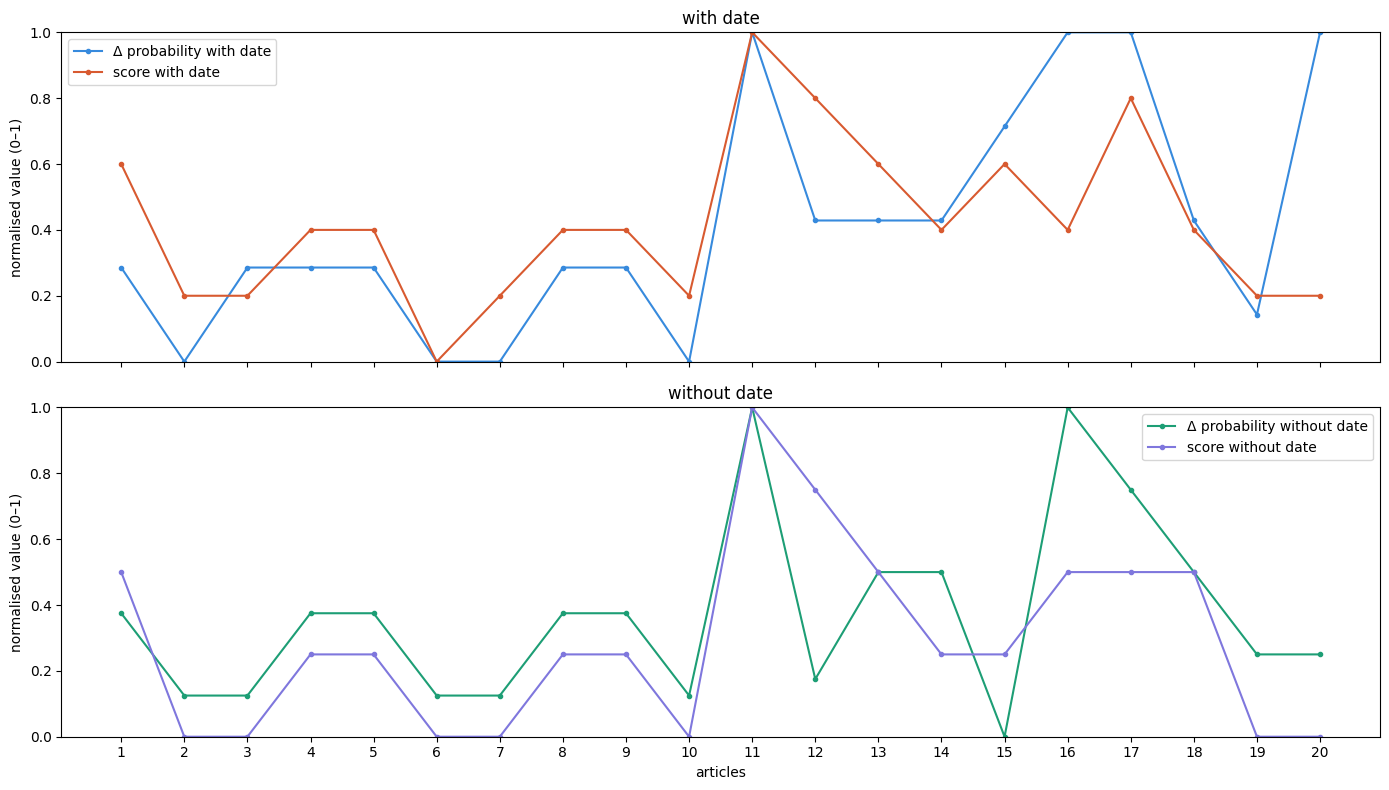


Article index reference:
    1. AfD’s Self-Proclaimed Saviors of Berlin - Berliner Morgenpost
    2. Primary election preview; Meet the candidates for WS/FCS Board of Education at-large, district seats - wfmynews2.com
    3. It's Election Day in Wisconsin; time, voting, polling places, ballot - Milwaukee Journal Sentinel
    4. Alternative for Germany (AfD) | Beliefs, Platform, Election Results, & Scandals - Britannica
    5. German election polls 2026 - Statista
    6. SPD tops Berlin poll, AfD enters assembly - DW.com
    7. German Chancellor Merz's conservatives set to win state election - Reuters
    8. Germany's Merz says state election will not impact his coalition - Reuters
    9. AfD poll ahead of Greens in Berlin for the first time - The Berliner
   10. Germany's Merz faces second state election test on Sunday - Reuters
   11. Hormuz shipping traffic remains at a trickle as US-Iran deadlock deepens - Reuters
   12. Maersk profit drops, maintains 2026 outlook despite Hormuz un

In [27]:
import json
import matplotlib.pyplot as plt

with open("data/political_markets/comparison/llm_scores_gnews_partial.json") as f:
    results = json.load(f)

with open("data/political_markets/comparison/articles_gnews_package_standard.json") as f:
    originals = json.load(f)

# Lookup: (question, query, i) -> title
orig_lookup = {}
for market in originals:
    question = market.get("question", "")
    for query_obj in market.get("queries", []):
        query = query_obj.get("query", "")
        for i, article in enumerate(query_obj.get("articles", [])):
            orig_lookup[(question, query, i)] = article.get("title", "(no title)")

# Lookup: question -> prob_without_article
prob_base_lookup = {m.get("question", ""): m.get("prob_without_article") for m in originals}

keys = ["probability_with_date", "probability_without_date", "score_with_date", "score_without_date"]

articles = []
for market in results:
    question = market.get("question", "")
    prob_base = prob_base_lookup.get(question)
    for query_obj in market.get("queries", []):
        query = query_obj.get("query", "")
        for i, a in enumerate(query_obj.get("articles", [])):
            if all(a.get(k) is not None for k in keys) and prob_base is not None:
                a["_title"]      = orig_lookup.get((question, query, i), "(no title)")
                a["_prob_base"]  = prob_base
                articles.append(a)

def norm(vals):
    lo, hi = min(vals), max(vals)
    return [(v - lo) / (hi - lo) if hi != lo else 0.5 for v in vals]

x = range(1, len(articles) + 1)

delta_wd  = [abs(a["probability_with_date"]    - a["_prob_base"]) for a in articles]
delta_wod = [abs(a["probability_without_date"] - a["_prob_base"]) for a in articles]
score_wd  = [a["score_with_date"]    for a in articles]
score_wod = [a["score_without_date"] for a in articles]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, series, title in [
    (ax1, [
        (norm(delta_wd),  "Δ probability with date", "#378ADD"),
        (norm(score_wd),  "score with date",          "#D85A30"),
    ], "with date"),
    (ax2, [
        (norm(delta_wod), "Δ probability without date", "#1D9E75"),
        (norm(score_wod), "score without date",          "#7F77DD"),
    ], "without date"),
]:
    for vals, label, color in series:
        ax.plot(x, vals, label=label, color=color, linewidth=1.5, marker="o", markersize=3)
    ax.set_title(title)
    ax.set_ylabel("normalised value (0–1)")
    ax.set_ylim(0, 1)
    ax.legend()

ax2.set_xlabel("articles")
ax2.set_xticks(list(x))
plt.tight_layout()
plt.show()

print("\nArticle index reference:")
for i, a in enumerate(articles, 1):
    print(f"  {i:>3}. {a['_title']}")